<a href="https://colab.research.google.com/github/cristiandmarin7-jpg/CoderhouseCristianM/blob/Poyecto-DS1/VF-ProyectoDS_ParteI_Marin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto Final - Visualizaciones en python
#Primera Entrega

#Abstract

Este proyecto utiliza el dataset “Spotify_Popularity.Songs” proveniente de Kaggle, que contiene más de 900 canciones populares en la plataforma hasta 2023. La base de datos incluye canciones de todos los generos musicales, con información sobre nombre de la canción, nombre del artista, año de lanzamiento, numero de reproducciones en diferentes plataformas y características de audio como bailabilidad, energía, volumen, tempo, etc.

El objetivo del proyecto es explorar las canciones que mas escuchan las personas en la plataforma desde una perspectiva descriptiva y visual, respondiendo preguntas de interés sobre las canciones del datasets, el artista con mas canciones populares en la plataforma y su distribución por año de lanzamiento. Para ello se aplican técnicas de análisis univariado, bivariado y multivariado, utilizando herramientas como Matplotlib, Seaborn y pandas.

Se comienza con una limpieza básica y detección de valores faltantes, seguida de visualizaciones que permiten responder preguntas clave. Este análisis exploratorio permitirá sentar las bases para futuros trabajos de predicción, segmentación o recomendaciones basadas en contenido.

#Preguntas/ hipotesis de interes
1. ¿Que artista cuenta con la mayor cantidad de canciones populares?
2. ¿Que relacion existe entre la bailabilidad y la energia en las canciones?
3. ¿En que decadas las canciones presentan un mayor porcentaje de energia?
4. ¿Cual es la correlación entre cada uno de los atributos musicales de las canciones?
5. ¿ En que plataforma tienen la mayor cantidad de streems las canciones mas populares?


#Objetivo del proyecto

El objetivo de este proyecto es desarrollar un modelo predictivo que permita estimar que caracteristicas tienen las canciones mas populares en spotify en cuanto artistas, atributos, reproducciones, año de lanzamiento entre otros aspectos. Esta predicción facilitará el análisis de la musica mas escuchada en las plataformas y como estas variables influyen en una mayor cantidad de reproducciones y por ende una mayor popularidad.

#Visualizaciones y analisis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#cargar datos
df = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTy24g8jYEB9MSyaGBEzdOjhSu4SnAvY9S8uULa16D5ECAZkbRUYK2bYW_xk0BsFHEZ9vOfnQM-sl-V/pub?gid=0&single=true&output=csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [3]:
#@title Missing Values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]


#Analizando el dataset observamos que si tenemos valores faltantes en las columnas Key, in shazam_charts. Se dejaran o imputaran segun analisis

,0
key,95
in_shazam_charts,50


In [4]:
#@title 1. Analisis Univariado



/tmp/ipython-input-2477909540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artist_counts.values, y=artist_counts.index, palette="viridis")


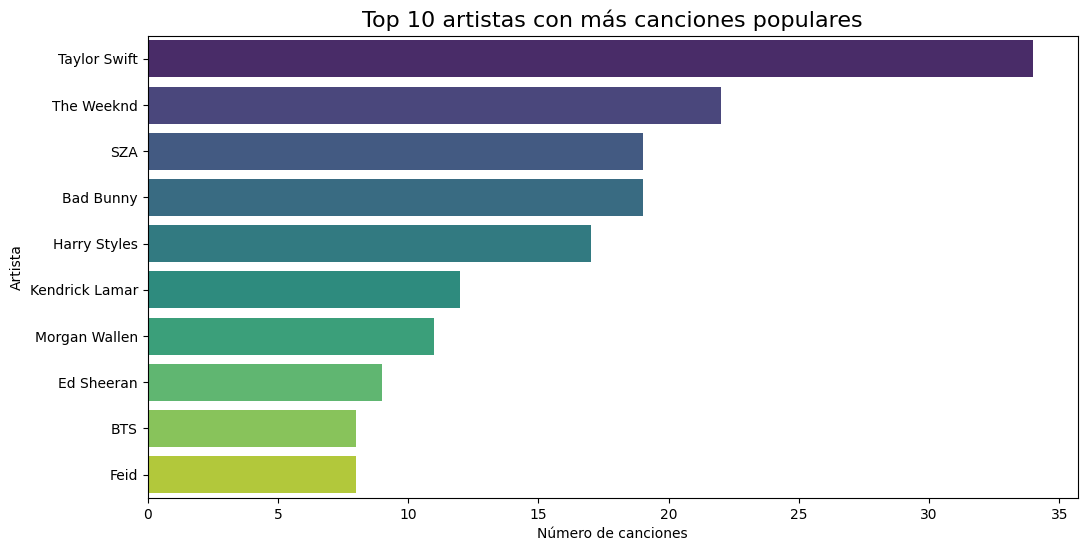

In [5]:
#@title Artista con el mayor numero de canciones mas populares

artist_counts = df['artist(s)_name'].value_counts().head(10)  # Top 10 artistas
plt.figure(figsize=(12,6))
sns.barplot(x=artist_counts.values, y=artist_counts.index, palette="viridis")

plt.title("Top 10 artistas con más canciones populares", fontsize=16)
plt.xlabel("Número de canciones")
plt.ylabel("Artista")
plt.show()

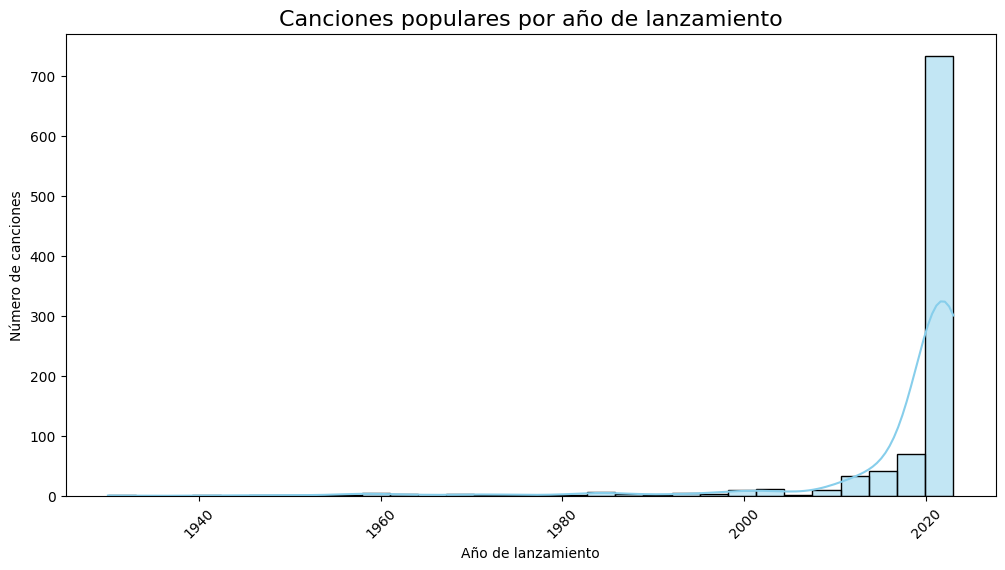

In [6]:
#@title Distribución por año de lanzamiento de las canciones

plt.figure(figsize=(12,6))
sns.histplot(df['released_year'], bins=30, kde=True, color="skyblue")

plt.title("Canciones populares por año de lanzamiento", fontsize=16)
plt.xlabel("Año de lanzamiento")
plt.ylabel("Número de canciones")
plt.xticks(rotation=45)
plt.show()

In [7]:
#@title 2. Analisis Bivariado



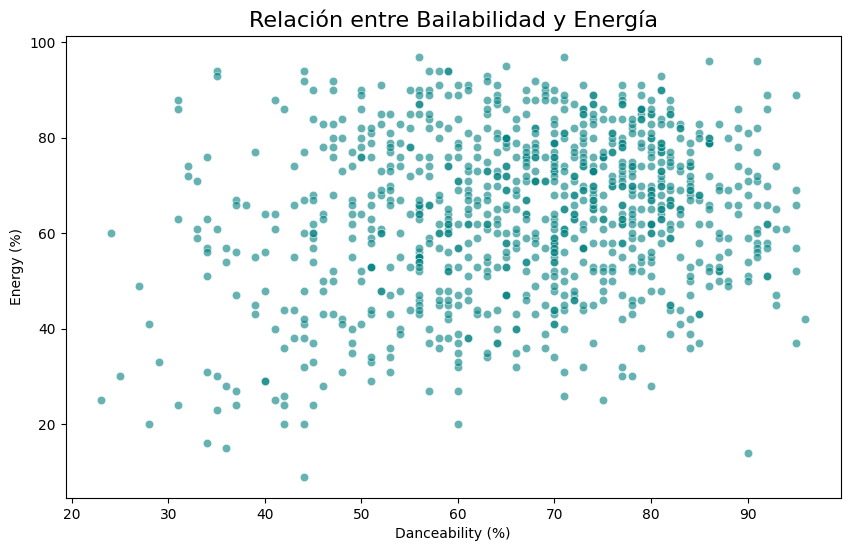

In [8]:
#@title Bailabilidad vs energia de las canciones

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="danceability_%", y="energy_%", alpha=0.6, color="teal")

plt.title("Relación entre Bailabilidad y Energía", fontsize=16)
plt.xlabel("Danceability (%)")
plt.ylabel("Energy (%)")
plt.show()

/tmp/ipython-input-1026710639.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="decade", y="energy_%", palette="muted")


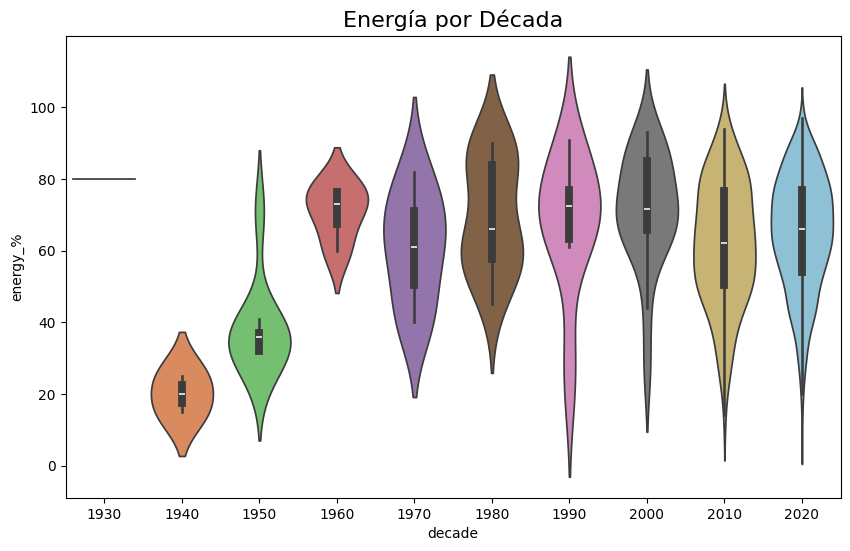

In [9]:
#@title %Energia de las canciones por decada

df["decade"] = (df["released_year"] // 10) * 10

plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="decade", y="energy_%", palette="muted")
plt.title("Energía por Década", fontsize=16)
plt.show()

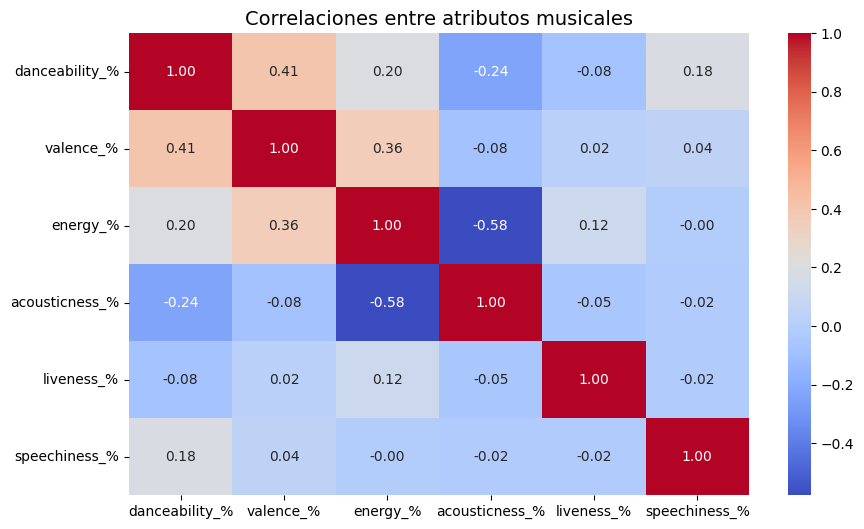

In [10]:
#@title Correlaciones atributos musicales

plt.figure(figsize=(10,6))
sns.heatmap(df[["danceability_%","valence_%","energy_%","acousticness_%","liveness_%","speechiness_%"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlaciones entre atributos musicales", fontsize=14)
plt.show()


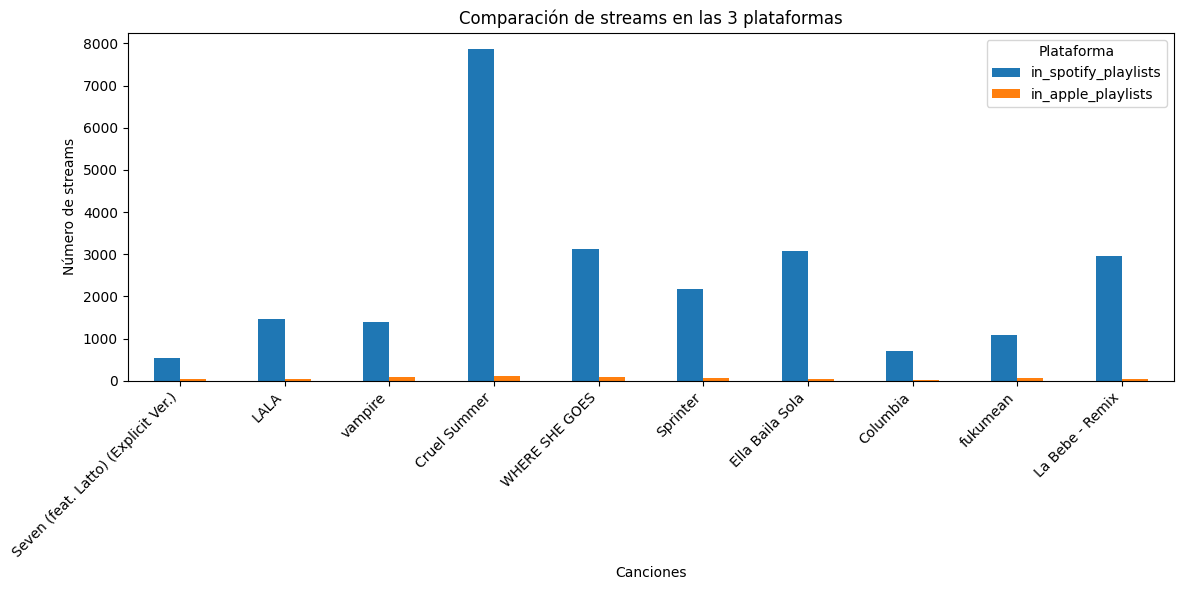

In [11]:
#@title Analisis canciones por plataforma

top_songs = df[['track_name', 'in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']].head(10)
top_songs.set_index('track_name').plot(kind='bar', figsize=(12,6))
plt.title("Comparación de streams en las 3 plataformas")
plt.ylabel("Número de streams")
plt.xlabel("Canciones")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Plataforma")
plt.tight_layout()
plt.show()



#Conclusiones preeliminares

1. El artista con la mayor cantidad de canciones populares en el dataset es Taylor Swift
2. La correlación entre la bailabilidad y la energia de las canciones es positiva. Es decir que las canciones mas bailables tienden a tener mayor energia.
3. La energía musical aumentó notablemente a partir de la decada de los 60s, consolidándose como característica central de la música popular.
4. El correlación más fuerte es energía vs. acústica, lo que refleja claramente la diferencia entre canciones electrónicas/potentes y acústicas/suaves. Adicionalmente, La bailabilidad y el “valence” muestran que la música alegre también suele invitar más al baile.
5. Spotify es la plataforma dominante en cuanto a inclusión de estas canciones en playlists, superando a Apple Music por un margen enorme. La brecha entre plataformas indica que, al menos en este dataset, estar en playlists de Spotify tiene un impacto mucho mayor en la visibilidad de un artista.




In [12]:
#@title Acciones de limpieza del dataset

#Eliminar columnas poco informativas o con muchos nulos
df.drop(columns=['in_shazam_charts'], inplace= True) # This column is already missing.

# Imputar valores faltantes en la columna 'key' con el valor más frecuente (moda)
if 'key' in df.columns:
    df['key'].fillna(df['key'].mode()[0], inplace=True)
else:
    print("Column 'key' not found in DataFrame.")

print("\nValores faltantes después de la limpieza:")
print(df.isna().sum().sort_values(ascending=False))

df.head()


Valores faltantes después de la limpieza:
track_name              0
artist(s)_name          0
artist_count            0
released_year           0
released_month          0
released_day            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 0
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
bpm                     0
key                     0
mode                    0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
decade                  0
dtype: int64


/tmp/ipython-input-1446533652.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['key'].fillna(df['key'].mode()[0], inplace=True)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,decade
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,B,Major,80,89,83,31,0,8,4,2020
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,C#,Major,71,61,74,7,0,10,4,2020
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,F,Major,51,32,53,17,0,31,6,2020
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,A,Major,55,58,72,11,0,11,15,2010
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,A,Minor,65,23,80,14,63,11,6,2020


In [13]:
#@title Aplicar algun metodo de Outliers Detection

original_size = df.shape[0]
print(f"Tamaño original del dataset: {original_size}")

Tamaño original del dataset: 953


In [14]:
#@title Con IQR (Interquartile Range)

=== MÉTODO IQR ===
Total de datos originales: 953
Datos eliminados (outliers): 74
Porcentaje eliminados: 7.76%


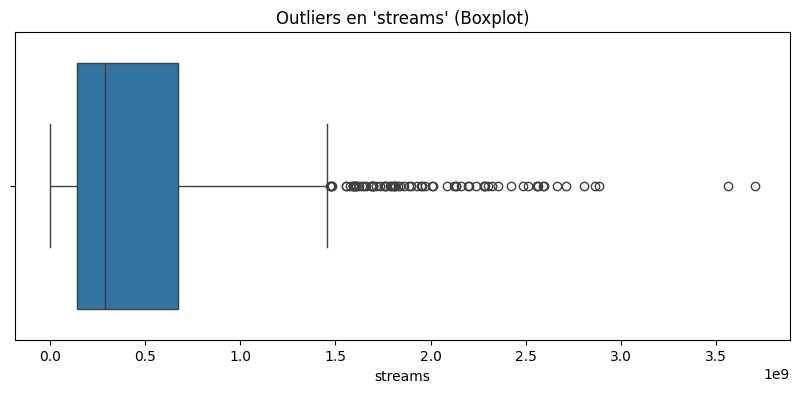

In [15]:
# Convertir 'streams' a numérico (remover comas)
df["streams"] = pd.to_numeric(
    df["streams"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce")

# --- Método 1: IQR ---
Q1 = df["streams"].quantile(0.25)
Q3 = df["streams"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df["streams"] < lower) | (df["streams"] > upper)]["streams"]
df_no_outliers_iqr = df[(df["streams"] >= lower) & (df["streams"] <= upper)]

total = len(df)
outliers_count = len(outliers_iqr)
remaining = len(df_no_outliers_iqr)
percentage_outliers = (outliers_count / total) * 100

print("=== MÉTODO IQR ===")
print(f"Total de datos originales: {total}")
print(f"Datos eliminados (outliers): {outliers_count}")
print(f"Porcentaje eliminados: {percentage_outliers:.2f}%")

# --- Visualización ---
plt.figure(figsize=(10,4))
sns.boxplot(x=df["streams"])
plt.title("Outliers en 'streams' (Boxplot)")
plt.show()